# **Optimizing Partial AUROC Loss (pAUCLoss)**
**Author**: Zhuoning Yuan, Dixian Zhu, Gang Li, Tianbao Yang
**Version**: 1.4.0


**Introduction**

In this tutorial, you will learn how to quickly train a Resnet18 model
by optimizing **One way Partial AUC (OPAUC)** with our novel `pAUCLoss`
[\[ref\]](https://proceedings.mlr.press/v162/zhu22g.html) on a binary
image classification task with the CIFAR-10 dataset. Please note that
`pAUCLoss` is a wrapper function for different types of partial AUC
losses. It currently supports two primary modes:

-   `pAUCLoss('1w')`: This mode aims to optimize One-way Partial AUC
    using `pAUC_DRO_Loss` as the backend and utilizing the `SOAPs`
    optimizer for optimization.
-   `pAUCLoss('2w')`: This mode aims to optimize Two-way Partial AUC
    using `tpAUC_KL_Loss` as the backend and utilizing the `SOTAs`
    optimizer for optimization.

This function allows for flexibility in handling varying partial AUC
loss in different scenarios. For the original tutorials, please refer to
[SOPA](https://colab.research.google.com/drive/1jY4QMyqf9il5gh6Tu0xxil_dnvYdkD--), [SOPA-s](https://colab.research.google.com/drive/1h92ZKJAXP5nDFT9k31DJCpCdKYwJdr6X), [SOTA-s](https://colab.research.google.com/drive/1rXIO2WSsMKmP0EpPlxhvUf_yY55ekNp-).
After completing this tutorial, you should be able to use LibAUC to
train your own models on your own datasets.

**Reference**:

If you find this tutorial helpful in your work, please cite our [library
paper](https://arxiv.org/abs/2306.03065) and the following papers:

``` RST
@inproceedings{zhu2022auc,
               title={When auc meets dro: Optimizing partial auc for deep learning with non-convex convergence guarantee},
               author={Zhu, Dixian and Li, Gang and Wang, Bokun and Wu, Xiaodong and Yang, Tianbao},
               booktitle={International Conference on Machine Learning},
               pages={27548--27573},
               year={2022},
               organization={PMLR}
            }
```



# **Installing LibAUC**

Let's start with installing our library here. In this tutorial, we will
use the lastest version for LibAUC by using `pip install -U`.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**


In [1]:
from libauc.losses import pAUCLoss
from libauc.optimizers import SOPAs
from libauc.models import resnet18 as ResNet18
from libauc.datasets import CIFAR10
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler
from libauc.metrics import auc_roc_score

import torchvision.transforms as transforms
from torch.utils.data import Dataset
import numpy as np
import torch
from PIL import Image

# Reproducibility

The following function `set_all_seeds` limits the number of sources of
randomness behaviors, such as model intialization, data shuffling, etcs.
However, completely reproducible results are not guaranteed across
PyTorch releases
[\[Ref\]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [3]:
def set_all_seeds(SEED):
   # REPRODUCIBILITY
   np.random.seed(SEED)
   torch.manual_seed(SEED)
   torch.cuda.manual_seed(SEED)
   torch.backends.cudnn.deterministic = True
   torch.backends.cudnn.benchmark = False    
set_all_seeds(2023)

# Loading datasets

In this step, we will use the
[CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) as benchmark
dataset. Before importing data to `dataloader`, we construct imbalanced
version for CIFAR10 by `ImbalanceDataGenerator`. Specifically, it first
randomly splits the training data by class ID (e.g., 10 classes) into
two even portions as the positive and negative classes, and then it
randomly removes some samples from the positive class to make it
imbalanced. We refer `imratio` to the
ratio of number of positive examples to number of all examples.

In [4]:
train_data, train_targets = CIFAR10(root='./data', train=True).as_array()
test_data, test_targets  = CIFAR10(root='./data', train=False).as_array()

imratio = 0.2
generator = ImbalancedDataGenerator(shuffle=True, verbose=True, random_seed=2023)
(train_images, train_labels) = generator.transform(train_data, train_targets, imratio=imratio)
(test_images, test_labels) = generator.transform(test_data, test_targets, imratio=imratio) 

Files already downloaded and verified
Files already downloaded and verified
#SAMPLES: 31250, CLASS 0.0 COUNT: 25000, CLASS RATIO: 0.8000
#SAMPLES: 31250, CLASS 1.0 COUNT: 6250, CLASS RATIO: 0.2000
#SAMPLES: 6250, CLASS 0.0 COUNT: 5000, CLASS RATIO: 0.8000
#SAMPLES: 6250, CLASS 1.0 COUNT: 1250, CLASS RATIO: 0.2000


We define the data input pipeline such as data augmentations. In this
tutorial, we use `RandomCrop`, `RandomHorizontalFlip`.

In [5]:
class ImageDataset(Dataset):
   def __init__(self, images, targets, image_size=32, crop_size=30, mode='train'):
      self.images = images.astype(np.uint8)
      self.targets = targets
      self.mode = mode
      self.transform_train = transforms.Compose([                                                
                              transforms.ToTensor(),
                              transforms.RandomCrop((crop_size, crop_size), padding=None),
                              transforms.RandomHorizontalFlip(),
                              transforms.Resize((image_size, image_size), antialias=True),
                              ])
      self.transform_test = transforms.Compose([
                             transforms.ToTensor(),
                             transforms.Resize((image_size, image_size), antialias=True),
                              ])
       
   def __len__(self):
      return len(self.images)

   def __getitem__(self, idx):
      image = self.images[idx]
      target = self.targets[idx]
      image = Image.fromarray(image.astype('uint8'))
      if self.mode == 'train':
            image = self.transform_train(image)
      else:
            image = self.transform_test(image)
      return image, target, idx

In [6]:
batch_size = 64

trainSet = ImageDataset(train_images, train_labels)
trainSet_eval = ImageDataset(train_images, train_labels,mode='test')
testSet = ImageDataset(test_images, test_labels, mode='test')

# **Configuration**

In [7]:
lr = 1e-3
margin = 0.6
gamma = 0.1
Lambda = 1.0
weight_decay = 2e-4
total_epoch = 60
decay_epoch = [30,45]
load_pretrain = False

# **Pretraining (Recommended)**

Following the original [paper](https://proceedings.mlr.press/v162/zhu22g.html), it's recommended to start from a pretrained checkpoint with cross-entropy loss to significantly boost models' performance. It includes a pre-training step with standard cross-entropy loss, and a Partial AUC maximization step that maximizes a Partial AUC surrogate loss of the pre-trained model.

In [8]:
from torch.optim import Adam
import warnings
warnings.filterwarnings('ignore')

load_pretrain = True
model = ResNet18(pretrained=False, last_activation=None, num_classes=1)
model = model.cuda()

loss_fn = torch.nn.BCELoss()
optimizer =Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

trainloader = torch.utils.data.DataLoader(trainSet, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testSet, batch_size=batch_size, shuffle=False, num_workers=2)


best_test = 0
for epoch in range(total_epoch):
    if epoch in decay_epoch:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.1 * param_group['lr']

    model.train()
    for idx, (data, targets, index) in enumerate(trainloader):
        data, targets, index  = data.cuda(), targets.cuda(), index.cuda()
        y_pred = model(data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ######***evaluation***####
    # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for j, data in enumerate(testloader):
            test_data, test_targets, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred_list.append(y_prob.cpu().detach().numpy())
            test_true_list.append(test_targets.numpy())
    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_pauc =  auc_roc_score(test_true, test_pred,max_fpr=0.3)
    if best_test < test_pauc:
        best_test = test_pauc
        torch.save(model.state_dict(), 'ce_pretrained_model_wrapper.pth')

    model.train()
    print("epoch: %s, test_pauc: %.4f, best_test_pauc: %.4f, lr: %.4f"%(epoch, test_pauc, best_test, optimizer.param_groups[0]['lr'] ))

epoch: 0, test_pauc: 0.6030, best_test_pauc: 0.6030, lr: 0.0010
epoch: 1, test_pauc: 0.6749, best_test_pauc: 0.6749, lr: 0.0010
epoch: 2, test_pauc: 0.6666, best_test_pauc: 0.6749, lr: 0.0010
epoch: 3, test_pauc: 0.6917, best_test_pauc: 0.6917, lr: 0.0010
epoch: 4, test_pauc: 0.6525, best_test_pauc: 0.6917, lr: 0.0010
epoch: 5, test_pauc: 0.7070, best_test_pauc: 0.7070, lr: 0.0010
epoch: 6, test_pauc: 0.7555, best_test_pauc: 0.7555, lr: 0.0010
epoch: 7, test_pauc: 0.7448, best_test_pauc: 0.7555, lr: 0.0010
epoch: 8, test_pauc: 0.7583, best_test_pauc: 0.7583, lr: 0.0010
epoch: 9, test_pauc: 0.7545, best_test_pauc: 0.7583, lr: 0.0010
epoch: 10, test_pauc: 0.7258, best_test_pauc: 0.7583, lr: 0.0010
epoch: 11, test_pauc: 0.7956, best_test_pauc: 0.7956, lr: 0.0010
epoch: 12, test_pauc: 0.8150, best_test_pauc: 0.8150, lr: 0.0010
epoch: 13, test_pauc: 0.8036, best_test_pauc: 0.8150, lr: 0.0010
epoch: 14, test_pauc: 0.7952, best_test_pauc: 0.8150, lr: 0.0010
epoch: 15, test_pauc: 0.8003, best_

# **Optimizing pAUC Loss**

We define `dataset`, `DualSampler` and `dataloader` here. By default, we
use `batch_size` 64 and we oversample the minority class with
`pos:neg=1:1` by setting `sampling_rate=0.5`.

In [9]:
sampling_rate = 0.5

sampler = DualSampler(trainSet, batch_size, sampling_rate=sampling_rate)
trainloader = torch.utils.data.DataLoader(trainSet, batch_size=batch_size, sampler=sampler, num_workers=2)
trainloader_eval = torch.utils.data.DataLoader(trainSet_eval, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testSet, batch_size=batch_size, shuffle=False, num_workers=2)

# **Model, Loss and Optimizer**

In [10]:
model = ResNet18(pretrained=False, last_activation=None, num_classes=1)
model = model.cuda()
# load pretrained model
if load_pretrain:
    PATH = 'ce_pretrained_model_wrapper.pth'
    state_dict = torch.load(PATH)
    filtered = {k:v for k,v in state_dict.items() if 'fc' not in k}
    msg = model.load_state_dict(filtered, False)
    print(msg)
    model.fc.reset_parameters()

loss_fn = pAUCLoss('1w', data_len=len(trainSet), margin=margin, gamma=gamma)
optimizer = SOPAs(model.parameters(), mode='adam', lr=lr, weight_decay=weight_decay)

_IncompatibleKeys(missing_keys=['fc.weight', 'fc.bias'], unexpected_keys=[])


# **Training**

Now it's time for training. And we evaluate partial AUC performance with
False Positive Rate(FPR) less than or equal to 0.3, i.e., FPR ≤ 0.3.

In [11]:
print ('Start Training')
print ('-'*30)

train_log, test_log = [], []
best_test = 0
for epoch in range(total_epoch):
    if epoch in decay_epoch:
        optimizer.update_lr(decay_factor=10)

    train_loss = []
    model.train() 
    for idx, (data, targets, index) in enumerate(trainloader):
        data, targets, index  = data.cuda(), targets.cuda(), index.cuda()
        y_pred = model(data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, targets, index)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

   ######***evaluation***####
   # evaluation on training sets
    model.eval()
    train_pred_list, train_true_list = [], []
    with torch.no_grad():
        for i, data in enumerate(trainloader_eval):
            train_data, train_targets, _ = data
            train_data = train_data.cuda()
            y_pred = model(train_data)
            y_prob = torch.sigmoid(y_pred)
            train_pred_list.append(y_prob.cpu().detach().numpy())
            train_true_list.append(train_targets.cpu().detach().numpy())
    train_true = np.concatenate(train_true_list)
    train_pred = np.concatenate(train_pred_list)

    train_pauc = auc_roc_score(train_true, train_pred, max_fpr=0.3)
    train_loss = np.mean(train_loss)
    train_log.append(train_pauc)    

   # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for j, data in enumerate(testloader):
            test_data, test_targets, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred_list.append(y_prob.cpu().detach().numpy())
            test_true_list.append(test_targets.numpy())
    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_pauc =  auc_roc_score(test_true, test_pred,max_fpr=0.3)
    test_log.append(test_pauc)
    if best_test < test_pauc:
        best_test = test_pauc

    model.train()    
    # print results
    print("epoch: %s, train_loss: %.4f, train_pauc: %.4f, test_pauc: %.4f, best_test_pauc: %.4f, lr: %.5f"%(epoch, train_loss, train_pauc, test_pauc, best_test, optimizer.lr ))    

Start Training
------------------------------
epoch: 0, train_loss: 0.3522, train_pauc: 0.9630, test_pauc: 0.8541, best_test_pauc: 0.8541, lr: 0.00100
epoch: 1, train_loss: 0.0697, train_pauc: 0.9768, test_pauc: 0.8649, best_test_pauc: 0.8649, lr: 0.00100
epoch: 2, train_loss: 0.0506, train_pauc: 0.9738, test_pauc: 0.8564, best_test_pauc: 0.8649, lr: 0.00100
epoch: 3, train_loss: 0.0469, train_pauc: 0.9654, test_pauc: 0.8444, best_test_pauc: 0.8649, lr: 0.00100
epoch: 4, train_loss: 0.0520, train_pauc: 0.9526, test_pauc: 0.8472, best_test_pauc: 0.8649, lr: 0.00100
epoch: 5, train_loss: 0.0553, train_pauc: 0.9336, test_pauc: 0.8261, best_test_pauc: 0.8649, lr: 0.00100
epoch: 6, train_loss: 0.0549, train_pauc: 0.9498, test_pauc: 0.8424, best_test_pauc: 0.8649, lr: 0.00100
epoch: 7, train_loss: 0.0581, train_pauc: 0.9371, test_pauc: 0.8402, best_test_pauc: 0.8649, lr: 0.00100
epoch: 8, train_loss: 0.0574, train_pauc: 0.9286, test_pauc: 0.8284, best_test_pauc: 0.8649, lr: 0.00100
epoch: 9,

# **Visualization**

Now, let's see the learning curves for optimizing pAUC from scratch and from a pretrained model with cross entropy loss.

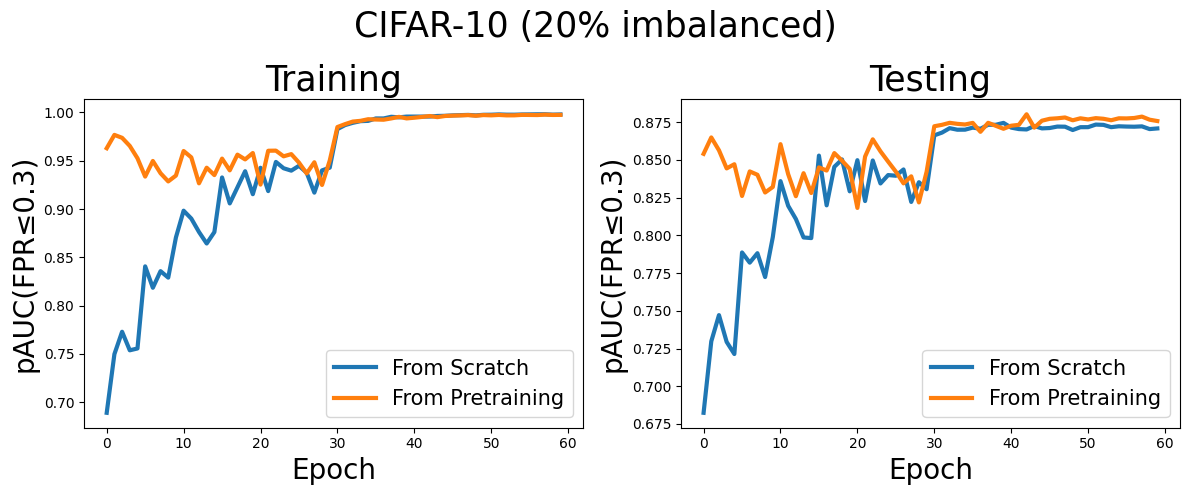

In [2]:
import matplotlib.pyplot as plt
import numpy as np
train_log= [0.9629983121568626, 0.976789697254902, 0.9737728125490197, 0.9653674415686273, 0.9526080000000001, 0.9336441725490195, 0.9497985317647059, 0.9371098352941176, 0.9286405458823529, 0.9346945380392156, 0.9601394321568628, 0.953512702745098, 0.9266596831372549, 0.9428325396078432, 0.9351774494117648, 0.9522345788235294, 0.9401062211764706, 0.9563442384313725, 0.9514192501960784, 0.9580526368627451, 0.9253358619607843, 0.9603840376470587, 0.9605023058823529, 0.9546136219607844, 0.9568967592156863, 0.9480975999999999, 0.9369100862745098, 0.9484633725490195, 0.9249502117647059, 0.9502059231372548, 0.9849486870588235, 0.9879563984313726, 0.9905859952941177, 0.9913526462745099, 0.9930277772549019, 0.9927193474509803, 0.9925047341176472, 0.9938547639215686, 0.9954592501960785, 0.993869954509804, 0.9945825756862745, 0.995418591372549, 0.996329662745098, 0.9951745380392156, 0.9963752847058824, 0.9967506447058823, 0.9969702023529412, 0.9972820956862744, 0.9966350243137254, 0.9973091764705881, 0.9970341521568626, 0.9974569160784313, 0.9970073286274509, 0.997043074509804, 0.9975259356862745, 0.9974475294117646, 0.9973477584313726, 0.9977820172549019, 0.9974407278431374, 0.9975082290196078]
test_log = [0.8540740392156863, 0.8649267450980391, 0.8564147450980393, 0.8444150588235293, 0.8471686274509804, 0.826121725490196, 0.8424131764705882, 0.8401847843137256, 0.8284373333333332, 0.8320996078431373, 0.8604749803921569, 0.840553725490196, 0.8259722352941177, 0.8412304313725489, 0.8280956862745098, 0.8450829803921568, 0.843001725490196, 0.854564862745098, 0.8495196862745098, 0.8440784313725489, 0.8182186666666666, 0.8522569411764706, 0.8636740392156863, 0.8557358431372548, 0.8489019607843137, 0.8422538039215686, 0.8344840784313725, 0.8391745882352941, 0.8218570980392157, 0.8421825882352941, 0.8723526274509803, 0.8732980392156863, 0.8746343529411764, 0.8739411764705883, 0.8735287843137255, 0.8745794509803921, 0.8686682352941176, 0.8746359215686275, 0.8726382745098038, 0.8706779607843138, 0.8727118431372549, 0.8732894117647059, 0.880304156862745, 0.8714334117647058, 0.8760409411764706, 0.8772798431372548, 0.8776307450980392, 0.8781731764705882, 0.8763093333333334, 0.8776247843137255, 0.8768696470588234, 0.8777276862745098, 0.8773055686274509, 0.8763356862745098, 0.877628862745098, 0.8775463529411764, 0.8778290196078431, 0.8787496470588235, 0.876702431372549, 0.8758170980392157]
train_log_scratch = [0.6890966588235294, 0.7498066949019607, 0.77299424, 0.7538028737254903, 0.7556846180392157, 0.8407256533333333, 0.8185373364705881, 0.8357328627450981, 0.8290430870588235, 0.8706400188235295, 0.8983218823529411, 0.8901459952941176, 0.8762650792156863, 0.8643537192156863, 0.8762003952941176, 0.9327183498039215, 0.9058492549019608, 0.9225154133333333, 0.9391776564705883, 0.9153873443137255, 0.9427768156862745, 0.918611105882353, 0.9488297160784314, 0.9422692141176472, 0.9397862211764705, 0.9447884047058823, 0.9376482133333333, 0.9170201662745099, 0.9400590368627451, 0.9428715294117647, 0.9827926776470589, 0.9869608282352941, 0.9892946447058824, 0.9910100705882354, 0.9913128219607843, 0.993834779607843, 0.9938273317647058, 0.9955538698039215, 0.9949663435294117, 0.9957406619607845, 0.9957660737254902, 0.9957580674509803, 0.9957963294117649, 0.9963942901960784, 0.9965594917647058, 0.9969945600000001, 0.9972550839215686, 0.9974924862745098, 0.9969971074509804, 0.997616803137255, 0.9976887654901962, 0.9980113945098039, 0.9977375623529412, 0.9977079843137253, 0.9979535686274509, 0.998025951372549, 0.998142908235294, 0.9981611168627451, 0.9977764141176471, 0.9979765709803923]
test_log_scratch = [0.6823946666666666, 0.7297479215686274, 0.747155137254902, 0.7293926274509804, 0.7213540392156863, 0.7886792156862745, 0.7819234509803922, 0.7881909019607842, 0.7723794509803921, 0.7988341960784313, 0.8359945098039215, 0.8195965490196079, 0.8108655686274511, 0.7986409411764706, 0.7982105098039216, 0.852886274509804, 0.819928156862745, 0.8454426666666666, 0.8503579607843137, 0.8292087843137255, 0.8498487843137255, 0.8227733333333334, 0.8496687058823529, 0.8344301176470588, 0.84, 0.8395469803921568, 0.8437207843137255, 0.8221675294117646, 0.8352611764705882, 0.8306180392156863, 0.8663220392156863, 0.8681480784313725, 0.8710854901960785, 0.8700506666666667, 0.8700886274509803, 0.8714505098039216, 0.8706748235294117, 0.8733140392156862, 0.873332705882353, 0.874576, 0.8714436078431371, 0.8704718431372549, 0.8702296470588236, 0.8724760784313725, 0.8709339607843137, 0.8711752156862745, 0.8721429019607843, 0.8720614901960784, 0.869857725490196, 0.8717300392156864, 0.8717584313725489, 0.8734641568627451, 0.8732724705882353, 0.8717474509803922, 0.8723347450980391, 0.8721515294117648, 0.8720542745098039, 0.8722836078431372, 0.87048, 0.8709046274509804]


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12,5))
plt.suptitle('CIFAR-10 (20% imbalanced)',fontsize=25)

x=np.arange(len(train_log))
ax0.plot(x, train_log_scratch,  label='From Scratch', linewidth=3)
ax0.plot(x, train_log,  label='From Pretraining', linewidth=3)
ax0.set_title('Training',fontsize=25)
ax1.plot(x, test_log_scratch, label='From Scratch', linewidth=3)
ax1.plot(x, test_log, label='From Pretraining', linewidth=3)
ax1.set_title('Testing',fontsize=25)

ax0.legend(fontsize=15)
ax1.legend(fontsize=15)
ax0.set_ylabel('pAUC(FPR≤0.3)', fontsize=20)
ax0.set_xlabel('Epoch', fontsize=20)
ax1.set_ylabel('pAUC(FPR≤0.3)', fontsize=20)
ax1.set_xlabel('Epoch', fontsize=20)

plt.tight_layout()
plt.savefig('pauc_wrapper_p.png')